# Tutorial 9: diffusion and flow matching, built by hand
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T09_diffusion_flow.ipynb) · [Recap slides](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T09_diffusion_flow_recap.pdf)

Plan for today (≈ 75 min):
0. Recap slides (15 min)
1. Lecture recap: DDPM, guidance, latent diffusion / DiT, flow matching, reflow, one-step models, video (5 min)
2. DDPM: forward noising, ε-prediction loss, ancestral sampler; 2D toy, then MNIST (15 min)
3. Flow matching: straight path, velocity loss, Euler sampler; quality vs number of steps (12 min)
4. Reflow: straighten the paths, sample in 1–4 steps (10 min)
5. Classifier-free guidance on MNIST, with the DDPM model from 2 (8 min)
6. Guidance trades diversity for fidelity: measured on a 2D toy (8 min)
7. If time: DDIM, the deterministic sampler for the DDPM model

Runs on CPU (Colab or laptop) in under 10 minutes; all models are small and briefly trained. Cells marked ✏️ are for you to try.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("diffusers") is None:          # used only for the reference checks
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "diffusers"], check=True)

import math, time, random, copy, warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from diffusers import DDPMScheduler
from diffusers.models.embeddings import get_timestep_embedding
from scipy.integrate import solve_ivp
from scipy.spatial import cKDTree

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
def seed_all(s=0):
    torch.manual_seed(s); random.seed(s); np.random.seed(s)
seed_all(0)
T_START = time.time()
print("device:", device)

device: mps


## 1. Lecture recap

**Time convention used in this notebook.** For flow matching, **$t=0$ is noise and $t=1$ is data**, as in Lecture 10b (slide 3). Some sources (the rectified-flow code slide in 10b, `diffusers`' flow schedulers) run the other way; their velocity is then minus ours. DDPM keeps its own *step index* $k = 0,\dots,K-1$ that counts noising steps ($k=K-1$ is pure noise, as in Lecture 10 and `diffusers`). We write $k$, never $t$, for it.

**DDPM** (Ho et al., 2020). A fixed forward process adds Gaussian noise with a schedule $\beta_1,\dots,\beta_K$; with $\alpha_k = 1-\beta_k$ and $\bar\alpha_k=\prod_{i\le k}\alpha_i$ it has a closed form
$$q(x_k\mid x_0) = \mathcal N\big(\sqrt{\bar\alpha_k}\,x_0,\;(1-\bar\alpha_k)I\big),\qquad x_k = \sqrt{\bar\alpha_k}\,x_0 + \sqrt{1-\bar\alpha_k}\,\varepsilon .$$
One network is trained to undo it. Predicting $x_0$, $\varepsilon$ or the score are equivalent (Lecture 10: $\hat x_0 = (x_k-\sqrt{1-\bar\alpha_k}\,\hat\varepsilon)/\sqrt{\bar\alpha_k}$, and $\nabla\log p(x_k) = -\hat\varepsilon/\sqrt{1-\bar\alpha_k}$). We use Ho et al.'s **ε-prediction** loss $\;\mathbb E_{x_0,k,\varepsilon}\,\|\varepsilon_\theta(x_k,k)-\varepsilon\|^2$. Sampling is **ancestral**: start at $x_{K}\sim\mathcal N(0,I)$ and draw $x_{k-1}\sim\mathcal N(\mu_\theta(x_k,k),\sigma_k^2 I)$, one network call per step.

**Classifier-free guidance** (Ho & Salimans, 2022). Train one network with the label dropped (replaced by a null label ∅) 10–20 % of the time. At sampling, combine
$$v_w = v(x\mid\varnothing) + w\,\big(v(x\mid y) - v(x\mid\varnothing)\big),$$
$w=1$: plain conditional model; $w>1$: extrapolate away from the unconditional prediction (the lecture's $\gamma$).

**Latent diffusion / DiT.** Run the same process in the latent space of a pretrained VAE (8× smaller per side for Stable Diffusion), and replace the U-Net by a transformer on latent patches (DiT, MM-DiT). Nothing in this notebook changes; only $x$ becomes a latent.

**Flow matching / rectified flow** (Lipman et al.; Liu et al.; Albergo & Vanden-Eijnden, ICLR 2023). Pair noise $x_0\sim\mathcal N(0,I)$ with data $x_1$, take the straight line $x_t = t\,x_1 + (1-t)\,x_0$, and regress its velocity:
$$\mathcal L_{\rm FM} = \mathbb E_{t,x_0,x_1}\,\|v_\theta(x_t,t) - (x_1-x_0)\|^2 .$$
The minimizer is the *marginal* velocity $\mathbb E[x_1-x_0\mid x_t]$, which transports noise to data; sample by integrating $\dot x = v_\theta(x,t)$ from $t=0$ to $1$ (Euler). Diffusion is the special case with a Gaussian path $x_t = \alpha_t x_1 + \sigma_t x_0$.

**Few steps.** One Euler step is exact only if the marginal paths are straight. Where conditional lines cross, the marginal field curves. **Reflow**: generate pairs $(x_0, \mathrm{ODE}(x_0))$ with the trained model and retrain on them; these pairs do not cross, so paths straighten and 1–2 steps suffice. Distillation, **consistency models** (map any point on a trajectory to its end point) and flow maps / MeanFlow reach one step by learning the ODE's solution operator directly.

**Video** generators are the same recipe with a time axis: a 3D VAE, spacetime patches as tokens, a flow-matching DiT, CFG.

### Shared pieces: 2D toy data, a sample-quality score, a time embedding

The toy: a mixture of 8 Gaussians on a circle of radius 2 (std 0.15), 8 labels = the 8 modes. Two numbers score a set of generated points:
- **on-mode**: fraction of samples within 3 std of some mode center (precision; data scores 0.99);
- **SWD**: sliced Wasserstein distance to fresh data (distribution match; lower is better). Computed on 5000 samples; data vs data scores ≈ 0.015, and differences below ≈ 0.03 are noise.

In [2]:
CENTERS = 2.0 * torch.stack([torch.cos(torch.arange(8) * 2 * math.pi / 8), torch.sin(torch.arange(8) * 2 * math.pi / 8)], 1)

def eight_gaussians(n, std=0.15):
    y = torch.randint(0, 8, (n,))
    return CENTERS[y] + std * torch.randn(n, 2), y

def on_mode(x, std=0.15):
    return (torch.cdist(x.cpu(), CENTERS).min(1).values < 3 * std).float().mean().item()

def swd(x, ref, n_proj=256):
    g = torch.Generator().manual_seed(0)
    d = torch.randn(2, n_proj, generator=g); d = d / d.norm(dim=0)
    a, b = (x.cpu() @ d).sort(0).values, (ref @ d).sort(0).values
    return (a - b).abs().mean().item()

NQ = 5000
REF, _ = eight_gaussians(NQ)
def quality(x):
    return on_mode(x), swd(x[:NQ], REF)

print("data vs data: on-mode %.3f, SWD %.3f" % quality(eight_gaussians(NQ)[0]))

data vs data: on-mode 0.989, SWD 0.015


Every network here gets its time as a **sinusoidal embedding** (Transformer positional encoding, used by DDPM and DiT): for $i = 0,\dots,d/2-1$, frequencies $f_i = 10000^{-i/(d/2)}$ and
$\mathrm{emb}(t) = [\sin(t f_0),\dots,\sin(t f_{d/2-1}), \cos(t f_0),\dots,\cos(t f_{d/2-1})]$. We feed DDPM steps and flow times on the same scale, $1000\,k/K$ and $1000\,t$.

In [3]:
def timestep_embedding(t, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(-math.log(max_period) * torch.arange(half, device=t.device) / half)
    args = t.float()[:, None] * freqs[None]
    return torch.cat([args.sin(), args.cos()], -1)

t_test = torch.tensor([0., 1., 37.5, 999.])
ref = get_timestep_embedding(t_test, 64, downscale_freq_shift=0)
print("max |mine − diffusers| =", (timestep_embedding(t_test, 64) - ref).abs().max().item())

max |mine − diffusers| = 0.0


In [4]:
class ToyNet(nn.Module):
    # MLP for 2D points: input [x, emb(t) (+ emb(label))] → output in R^2 (ε for DDPM, velocity for flows)
    def __init__(self, width=256, tdim=64, n_classes=None):
        super().__init__()
        self.tdim = tdim
        self.cls = nn.Embedding(n_classes + 1, tdim) if n_classes else None   # last index = null label ∅
        self.net = nn.Sequential(nn.Linear(2 + tdim, width), nn.SiLU(), nn.Linear(width, width), nn.SiLU(),
                                 nn.Linear(width, width), nn.SiLU(), nn.Linear(width, 2))
    def forward(self, x, t, y=None):
        e = timestep_embedding(t, self.tdim)
        if self.cls is not None:
            e = e + self.cls(y)
        return self.net(torch.cat([x, e], 1))

def train(model, loss_fn, get_batch, steps, lr=2e-3, log=4):
    # Adam + cosine decay; get_batch() → (x, y) on device; loss_fn(model, x, y) → scalar
    opt = torch.optim.Adam(model.parameters(), lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    t0, run = time.time(), 0.0
    for s in range(1, steps + 1):
        x, y = get_batch()
        loss = loss_fn(model, x, y)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        run += loss.item()
        if s % (steps // log) == 0:
            print(f"  step {s:5d}  loss {run / (steps // log):.4f}"); run = 0.0
    print(f"  trained in {time.time() - t0:.0f}s")
    return model

def toy_batch(n=512, std=0.15):
    x, y = eight_gaussians(n, std)
    return x.to(device), y.to(device)

## 2. DDPM

Further reading for this section: Stanford CME 296 (Spring 2026), [Lecture 1: DDPM / DDIM](https://cme296.stanford.edu/slides/spring26-cme296-lecture1.pdf) and [Lecture 2: score matching](https://cme296.stanford.edu/slides/spring26-cme296-lecture2.pdf).

### 2a. Forward process

Ho et al.'s linear schedule, $\beta$ from $10^{-4}$ to $0.02$ over 1000 steps, rescaled to $K=200$ steps (so $\bar\alpha_{K-1}$ is still ≈ 0).

In [5]:
K = 200
betas = torch.linspace(1e-4, 0.02, K) * (1000 / K)
abar = torch.cumprod(1 - betas, 0)
print(f"abar at k = 0, 50, 100, 199: {abar[0]:.4f}, {abar[50]:.4f}, {abar[100]:.4f}, {abar[199]:.2e}")

def q_sample(x0, k, eps):
    # x0: (n, ...) data, k: (n,) integer steps, eps: noise like x0
    a = abar.to(x0.device)[k].view(-1, *[1] * (x0.dim() - 1))
    return a.sqrt() * x0 + (1 - a).sqrt() * eps

abar at k = 0, 50, 100, 199: 0.9995, 0.5123, 0.0728, 3.03e-05


**Check.** (i) For a fixed $x_0$, the empirical mean and variance of $x_k$ over many noise draws must be $\sqrt{\bar\alpha_k}\,x_0$ and $1-\bar\alpha_k$. (ii) `diffusers.DDPMScheduler.add_noise` with the same betas must give the same $x_k$.

In [6]:
x0 = torch.tensor([1.5, -0.5]).repeat(200_000, 1)
for k in [10, 50, 199]:
    xk = q_sample(x0, torch.full((len(x0),), k), torch.randn_like(x0))
    print(f"k={k:3d}  mean {xk.mean(0).numpy().round(3)} vs {(abar[k].sqrt() * x0[0]).numpy().round(3)}   "
          f"var {xk.var(0).numpy().round(3)} vs {1 - abar[k].item():.3f}")

sched = DDPMScheduler(num_train_timesteps=K, trained_betas=betas.numpy(), clip_sample=False, timestep_spacing="trailing")
x0b, _ = eight_gaussians(64); eps = torch.randn_like(x0b); kb = torch.randint(0, K, (64,))
print("max |mine − diffusers add_noise| =", (q_sample(x0b, kb, eps) - sched.add_noise(x0b, eps, kb)).abs().max().item())

k= 10  mean [ 1.475 -0.492] vs [ 1.475 -0.492]   var [0.033 0.033] vs 0.033
k= 50  mean [ 1.073 -0.356] vs [ 1.074 -0.358]   var [0.486 0.488] vs 0.488
k=199  mean [ 0.009 -0.005] vs [ 0.008 -0.003]   var [0.999 0.999] vs 1.000
max |mine − diffusers add_noise| = 0.0


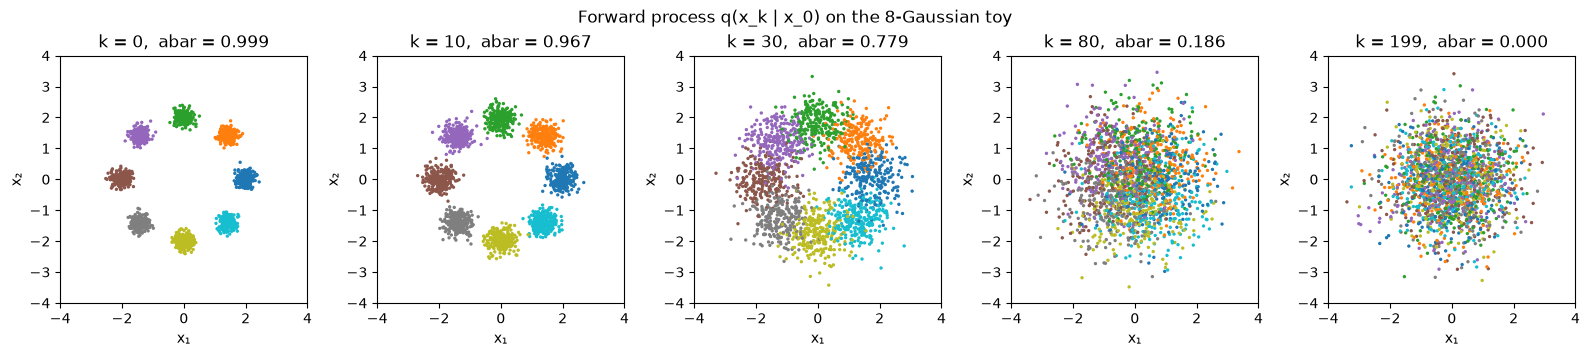

In [7]:
xd, yd = eight_gaussians(2000)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for ax, k in zip(axes, [0, 10, 30, 80, 199]):
    xk = q_sample(xd, torch.full((len(xd),), k), torch.randn_like(xd))
    ax.scatter(*xk.T, s=2, c=yd, cmap="tab10")
    ax.set(title=f"k = {k},  abar = {abar[k]:.3f}", xlim=(-4, 4), ylim=(-4, 4), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
plt.suptitle("Forward process q(x_k | x_0) on the 8-Gaussian toy"); plt.tight_layout(); plt.show()

### 2b. ε-prediction loss and training

In [8]:
def ddpm_loss(model, x0, y=None):
    k = torch.randint(0, K, (x0.shape[0],), device=x0.device)
    eps = torch.randn_like(x0)
    return F.mse_loss(model(q_sample(x0, k, eps), k * (1000 / K), y), eps)

**Check.** Same random draws, the noisy input built by `diffusers` instead: the two losses must agree. A network that outputs 0 must score $\mathbb E\|\varepsilon\|^2/d = 1$.

In [9]:
net_chk = ToyNet().to(device)
xb, _ = toy_batch()
seed_all(1); mine = ddpm_loss(net_chk, xb)
seed_all(1)
k = torch.randint(0, K, (len(xb),), device=device); eps = torch.randn_like(xb)
xk = sched.add_noise(xb.cpu(), eps.cpu(), k.cpu()).to(device)
ref = F.mse_loss(net_chk(xk, k * (1000 / K)), eps)
print(f"mine {mine.item():.5f}   diffusers-noised {ref.item():.5f}")
print(f"zero predictor: {ddpm_loss(lambda x, t, y=None: torch.zeros_like(x), xb).item():.3f} (should be ≈ 1)")

mine 1.01267   diffusers-noised 1.01267
zero predictor: 1.033 (should be ≈ 1)


In [10]:
seed_all(0)
ddpm_toy = train(ToyNet().to(device), ddpm_loss, toy_batch, steps=3000)

  step   750  loss 0.3160


  step  1500  loss 0.2549


  step  2250  loss 0.2445


  step  3000  loss 0.2395
  trained in 15s


### 2c. Ancestral sampler

We sample on a decreasing list of steps $k_1 > k_2 > \dots$ (all 200, or a subset to go faster). For a jump $k \to k'$ the effective $\beta = 1-\bar\alpha_k/\bar\alpha_{k'}$ (it equals $\beta_k$ when $k'=k-1$), and the DDPM posterior is
$$\mu = \frac{1}{\sqrt{1-\beta}}\Big(x_k - \frac{\beta}{\sqrt{1-\bar\alpha_k}}\,\hat\varepsilon\Big),\qquad \sigma^2 = \beta\,\frac{1-\bar\alpha_{k'}}{1-\bar\alpha_k},$$
with $\bar\alpha_{-1}=1$ after the last step, where no noise is added.

In [11]:
def trailing_steps(n):
    # n steps that start at k = K−1 ("trailing" spacing, Lin et al. 2024): e.g. n=4 → [199, 149, 99, 49]
    return (np.round(np.arange(K, 0, -K / n)).astype(int) - 1).tolist()

@torch.no_grad()
def ddpm_sample(model, n, ks, shape=(2,), y=None, gen=None):
    x = torch.randn(n, *shape, generator=gen).to(device)
    ab = abar.to(device)
    for i, k in enumerate(ks):
        k_prev = ks[i + 1] if i + 1 < len(ks) else -1
        ab_k = ab[k]
        ab_prev = ab[k_prev] if k_prev >= 0 else torch.tensor(1.0, device=device)
        beta = 1 - ab_k / ab_prev
        eps = model(x, torch.full((n,), k * 1000 / K, device=device), y)
        mean = (x - beta / (1 - ab_k).sqrt() * eps) / (1 - beta).sqrt()
        if k_prev >= 0:
            var = beta * (1 - ab_prev) / (1 - ab_k)
            x = mean + var.sqrt() * torch.randn(x.shape, generator=gen).to(device)
        else:
            x = mean
    return x

**Check.** `diffusers.DDPMScheduler.step` implements the same update (written via $\hat x_0$). With the same starting noise and the same generator, the whole 10-step trajectory must match.

In [12]:
def diffusers_sample(model, n, n_steps, gen):
    sched.set_timesteps(n_steps)
    x = torch.randn(n, 2, generator=gen)
    for k in sched.timesteps:
        with torch.no_grad():
            eps = model(x.to(device), torch.full((n,), k.item() * 1000 / K, device=device)).cpu()
        x = sched.step(eps, k, x, generator=gen).prev_sample
    return x

sched.set_timesteps(10)
print("steps (diffusers):", sched.timesteps.tolist())
print("steps (mine):     ", trailing_steps(10))
a = ddpm_sample(ddpm_toy, 500, trailing_steps(10), gen=torch.Generator().manual_seed(3)).cpu()
b = diffusers_sample(ddpm_toy, 500, 10, gen=torch.Generator().manual_seed(3))
print("max |mine − diffusers| over 500 samples:", (a - b).abs().max().item())

steps (diffusers): [199, 179, 159, 139, 119, 99, 79, 59, 39, 19]
steps (mine):      [199, 179, 159, 139, 119, 99, 79, 59, 39, 19]
max |mine − diffusers| over 500 samples: 6.67572021484375e-06


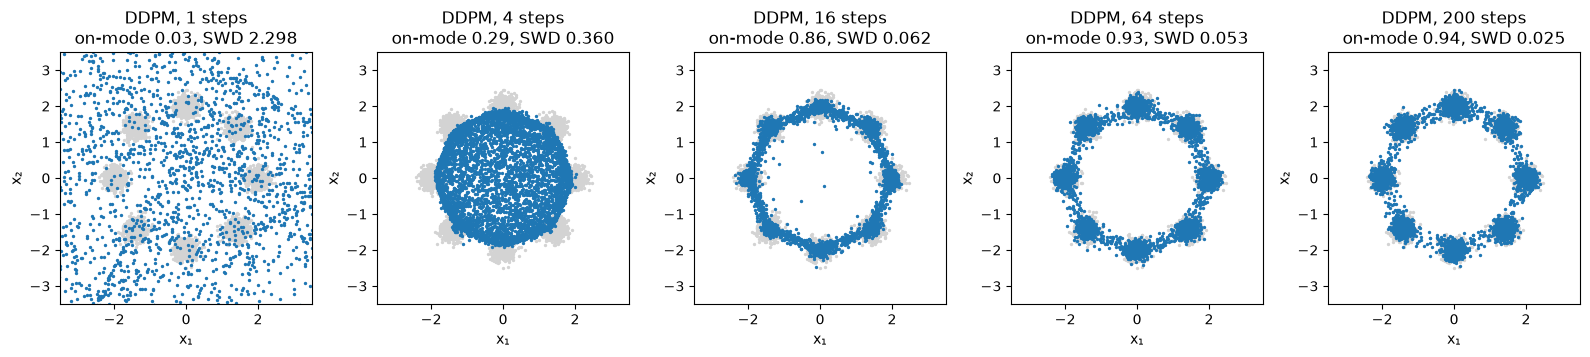

In [13]:
seed_all(0)
STEP_GRID = [1, 2, 4, 8, 16, 32, 64, 200]
res_ddpm = {}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for n_steps in STEP_GRID:
    xs = ddpm_sample(ddpm_toy, NQ, trailing_steps(n_steps)).cpu()
    res_ddpm[n_steps] = quality(xs)
    if n_steps in (1, 4, 16, 64, 200):
        ax = axes[[1, 4, 16, 64, 200].index(n_steps)]
        ax.scatter(*REF.T, s=2, c="lightgray"); ax.scatter(*xs.T, s=2)
        ax.set(title=f"DDPM, {n_steps} steps\non-mode {res_ddpm[n_steps][0]:.2f}, SWD {res_ddpm[n_steps][1]:.3f}",
               xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

With 64–200 steps the samples sit on the 8 modes (on-mode ≈ 0.93, data: 0.99). With few steps they do not. With 4 steps they fill the disc inside the ring. With 1 step they are scattered far outside it: the single step returns $\hat x_0 = (x - \sqrt{1-\bar\alpha_{K-1}}\,\hat\varepsilon)/\sqrt{\bar\alpha_{K-1}}$, and $1/\sqrt{\bar\alpha_{K-1}} \approx 180$ multiplies every error of $\hat\varepsilon$. DDPM's sampler needs ≥ 16 steps here.

✏️ Compute $1/\sqrt{\bar\alpha_k}$ for $k = 199, 150, 100$. Why is ε-prediction a poor parameterization for the first, noisiest step, and why does that not matter when steps are small?

### 2d. The same code on MNIST, with a small U-Net

Architecture background: CME 296 [Lecture 5: U-Net / DiT / MM-DiT](https://cme296.stanford.edu/slides/spring26-cme296-lecture5.pdf). Only the network changes: a 3-level U-Net (residual blocks, time embedding added to every block, skip connections by concatenation). To keep CPU training at about 3 minutes we resize MNIST to **16×16** and train for 800 steps (≈ 1.7 epochs). On a Colab GPU set `RES = 28`, `ch=(32, 64, 128)` and `steps=5000` for clean digits.

The U-Net also gets a class label, and during training we replace 10 % of the labels by a **null label** ∅ (index 10). The same network is then both a conditional model ($y$ given) and an unconditional one ($y=\varnothing$). Section 5 uses this for guidance.

In [14]:
RES = 16                                                      # 28 on a GPU
mnist = torchvision.datasets.MNIST("./data", train=True, download=True)
MX = mnist.data[:, None].float() / 255
if RES != 28:
    MX = F.interpolate(MX, size=RES, mode="bilinear", antialias=True)
MX = MX * 2 - 1                                               # (60000, 1, RES, RES) in [−1, 1]
MY = mnist.targets.clone()
NULL = 10                                                     # the null label ∅

def mnist_batch(n=128):
    i = torch.randint(0, len(MX), (n,))
    return MX[i].to(device), MY[i].to(device)

class ResBlock(nn.Module):
    def __init__(self, cin, cout, tdim):
        super().__init__()
        self.c1, self.c2 = nn.Conv2d(cin, cout, 3, padding=1), nn.Conv2d(cout, cout, 3, padding=1)
        self.n1, self.n2 = nn.GroupNorm(8, cout), nn.GroupNorm(8, cout)
        self.t = nn.Linear(tdim, cout)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()
    def forward(self, x, e):
        h = F.silu(self.n1(self.c1(x))) + self.t(e)[:, :, None, None]
        return F.silu(self.n2(self.c2(h))) + self.skip(x)

class UNet(nn.Module):
    def __init__(self, ch=(16, 32, 64), tdim=64, n_classes=None):
        super().__init__()
        self.tdim = tdim
        self.tmlp = nn.Sequential(nn.Linear(tdim, tdim), nn.SiLU(), nn.Linear(tdim, tdim))
        self.cls = nn.Embedding(n_classes + 1, tdim) if n_classes else None   # last index = null label ∅
        self.inc = nn.Conv2d(1, ch[0], 3, padding=1)
        self.d1, self.d2, self.d3 = ResBlock(ch[0], ch[0], tdim), ResBlock(ch[0], ch[1], tdim), ResBlock(ch[1], ch[2], tdim)
        self.u2, self.u1 = ResBlock(ch[2] + ch[1], ch[1], tdim), ResBlock(ch[1] + ch[0], ch[0], tdim)
        self.out = nn.Conv2d(ch[0], 1, 3, padding=1)
    def forward(self, x, t, y=None):
        e = self.tmlp(timestep_embedding(t, self.tdim))
        if self.cls is not None:
            e = e + self.cls(y)
        h1 = self.d1(self.inc(x), e)                                  # RES × RES
        h2 = self.d2(F.avg_pool2d(h1, 2), e)                          # RES/2
        h3 = self.d3(F.avg_pool2d(h2, 2), e)                          # RES/4
        u = self.u2(torch.cat([F.interpolate(h3, scale_factor=2), h2], 1), e)
        u = self.u1(torch.cat([F.interpolate(u, scale_factor=2), h1], 1), e)
        return self.out(u)

def show_digits(x, nrow, title, ax=None):
    grid = torchvision.utils.make_grid(x.cpu().clamp(-1, 1) * 0.5 + 0.5, nrow=nrow, padding=1, pad_value=1)
    ax = ax or plt.figure(figsize=(nrow * 0.6, len(x) / nrow * 0.6)).gca()
    ax.imshow(grid[0], cmap="gray"); ax.set_title(title); ax.axis("off")

print(f"U-Net parameters: {sum(p.numel() for p in UNet(n_classes=10).parameters()) / 1e6:.2f} M")

U-Net parameters: 0.15 M


In [15]:
def drop_labels(y, p, null):
    return torch.where(torch.rand(y.shape, device=y.device) < p, torch.full_like(y, null), y)

yy = torch.randint(0, 10, (100_000,))
yd = drop_labels(yy, 0.1, NULL)
print(f"fraction set to null: {(yd == NULL).float().mean():.4f} (expected 0.1);  kept labels unchanged: {bool((yd[yd != NULL] == yy[yd != NULL]).all())}")

fraction set to null: 0.1004 (expected 0.1);  kept labels unchanged: True


  step   200  loss 0.1087


  step   400  loss 0.0502


  step   600  loss 0.0446


  step   800  loss 0.0415
  trained in 28s


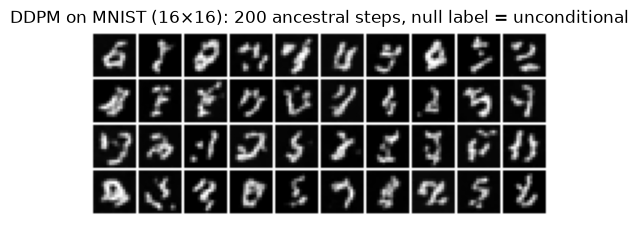

In [16]:
seed_all(0)
ddpm_mnist = train(UNet(n_classes=10).to(device), lambda m, x, y: ddpm_loss(m, x, drop_labels(y, 0.1, NULL)), mnist_batch, steps=800)
xs = ddpm_sample(ddpm_mnist, 40, trailing_steps(200), shape=(1, RES, RES), y=torch.full((40,), NULL, device=device))
show_digits(xs, 10, "DDPM on MNIST (16×16): 200 ancestral steps, null label = unconditional"); plt.show()

After 800 steps (1.7 epochs) on 16×16 images the unconditional samples (null label) are stroke-like and only a few are readable digits. Section 5 shows that the same network with labels and guidance does much better.
Nothing in the loss or the sampler knows that $x$ is an image: `q_sample` broadcasts over any shape. This is why latent diffusion is a drop-in change.

## 3. Flow matching

Further reading: CME 296 [Lecture 3: flow matching / rectified flow](https://cme296.stanford.edu/slides/spring26-cme296-lecture3.pdf).

Same toy, new objective. Straight path from noise ($t=0$) to data ($t=1$):
$$x_t = t\,x_1 + (1-t)\,x_0,\qquad \frac{d x_t}{dt} = x_1 - x_0,\qquad \mathcal L = \mathbb E\,\|v_\theta(x_t,t)-(x_1-x_0)\|^2 .$$
Compared with DDPM: no schedule, no $\bar\alpha$, no posterior variance; the sampler is an ODE solver.

In [17]:
def path(x0, x1, t):
    # x0: noise, x1: data, t: (n,) times in [0, 1]. Returns (x_t, dx_t/dt)
    tt = t.view(-1, *[1] * (x1.dim() - 1))
    return tt * x1 + (1 - tt) * x0, x1 - x0

def fm_loss(model, x1, y=None, x0=None):
    # x0 = None: fresh independent noise (flow matching); x0 given: a fixed coupling (reflow, section 4)
    x0 = torch.randn_like(x1) if x0 is None else x0
    t = torch.rand(x1.shape[0], device=x1.device)
    xt, u = path(x0, x1, t)
    return F.mse_loss(model(xt, 1000 * t, y), u)

**Check.** The target must be the time derivative of the path. `torch.func.jvp` differentiates `path` w.r.t. $t$ (forward-mode autograd); it must equal the returned velocity, and the endpoints must be noise and data.

In [18]:
x0c, x1c, tc = torch.randn(5, 2), torch.randn(5, 2), torch.rand(5)
(xt, u), (dxdt, _) = torch.func.jvp(lambda t: path(x0c, x1c, t), (tc,), (torch.ones(5),))
print("max |velocity − autograd d/dt| =", (u - dxdt).abs().max().item())
print("x_0 = noise:", torch.allclose(path(x0c, x1c, torch.zeros(5))[0], x0c),
      "  x_1 = data:", torch.allclose(path(x0c, x1c, torch.ones(5))[0], x1c))

max |velocity − autograd d/dt| = 0.0
x_0 = noise: True   x_1 = data: True


In [19]:
seed_all(0)
flow_toy = train(ToyNet().to(device), fm_loss, toy_batch, steps=3000)

  step   750  loss 2.0555


  step  1500  loss 1.9090


  step  2250  loss 1.8847


  step  3000  loss 1.8710
  trained in 21s


### Euler sampler

$x \leftarrow x + \Delta t\, v_\theta(x, t)$ on a uniform grid of $N$ steps. A velocity field is passed as a function `v(x, t)` with scalar `t`, so the same sampler serves the plain model, reflow and guidance.

In [20]:
def as_field(model, y=None):
    return lambda x, t: model(x, torch.full((len(x),), 1000 * t, device=x.device), y)

@torch.no_grad()
def euler(v, x0, n_steps, return_traj=False):
    x, traj = x0.to(device), [x0.to(device)]
    ts = torch.linspace(0, 1, n_steps + 1).tolist()
    for i in range(n_steps):
        x = x + (ts[i + 1] - ts[i]) * v(x, ts[i])
        traj.append(x)
    return (x, torch.stack(traj)) if return_traj else x

**Check.** Integrate the same trained field with `scipy`'s adaptive RK45 at tight tolerance. Euler is first order: the gap should shrink ≈ 10× per 10× more steps.

In [21]:
z = torch.randn(16, 2)
f = as_field(flow_toy)
def rhs(t, xflat):
    with torch.no_grad():
        return f(torch.tensor(xflat, dtype=torch.float32, device=device).view(-1, 2), t).cpu().numpy().ravel().astype(np.float64)
ref = torch.tensor(solve_ivp(rhs, (0, 1), z.numpy().ravel().astype(np.float64), rtol=1e-7, atol=1e-7).y[:, -1]).view(-1, 2).float()
for n_steps in [10, 100, 1000]:
    print(f"Euler {n_steps:4d} steps: max |Euler − RK45| = {(euler(f, z, n_steps).cpu() - ref).abs().max().item():.2e}")

Euler   10 steps: max |Euler − RK45| = 1.75e-01
Euler  100 steps: max |Euler − RK45| = 1.98e-02


Euler 1000 steps: max |Euler − RK45| = 2.08e-03


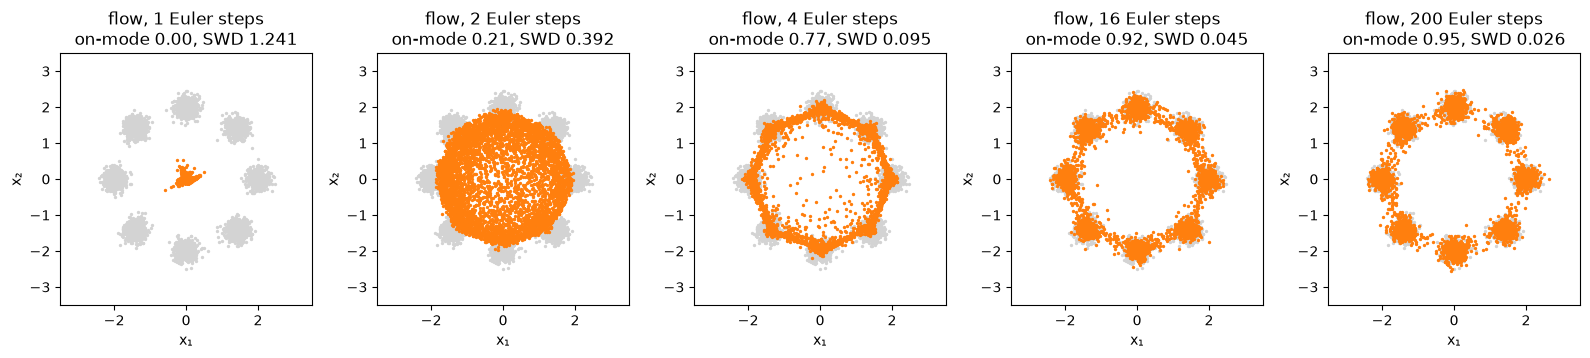

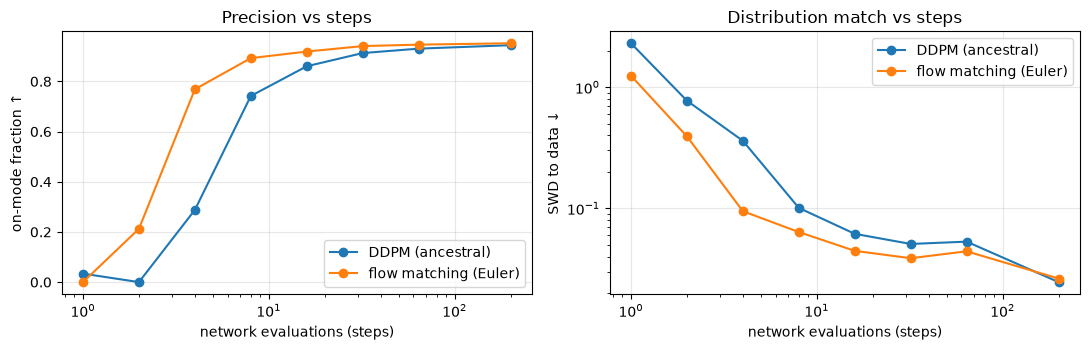

steps  | DDPM on-mode / SWD | flow on-mode / SWD
    1  |   0.03 / 2.298    |   0.00 / 1.241
    2  |   0.00 / 0.772    |   0.21 / 0.392
    4  |   0.29 / 0.360    |   0.77 / 0.095
    8  |   0.74 / 0.101    |   0.89 / 0.064
   16  |   0.86 / 0.062    |   0.92 / 0.045
   32  |   0.91 / 0.051    |   0.94 / 0.039
   64  |   0.93 / 0.053    |   0.95 / 0.044
  200  |   0.94 / 0.025    |   0.95 / 0.026


In [22]:
seed_all(0)
res_flow = {}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
for n_steps in STEP_GRID:
    xs = euler(as_field(flow_toy), torch.randn(NQ, 2), n_steps).cpu()
    res_flow[n_steps] = quality(xs)
    if n_steps in (1, 2, 4, 16, 200):
        ax = axes[[1, 2, 4, 16, 200].index(n_steps)]
        ax.scatter(*REF.T, s=2, c="lightgray"); ax.scatter(*xs.T, s=2, c="tab:orange")
        ax.set(title=f"flow, {n_steps} Euler steps\non-mode {res_flow[n_steps][0]:.2f}, SWD {res_flow[n_steps][1]:.3f}",
               xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for name, res, c in [("DDPM (ancestral)", res_ddpm, "tab:blue"), ("flow matching (Euler)", res_flow, "tab:orange")]:
    axes[0].plot(STEP_GRID, [res[n][0] for n in STEP_GRID], "o-", c=c, label=name)
    axes[1].plot(STEP_GRID, [res[n][1] for n in STEP_GRID], "o-", c=c, label=name)
axes[0].set(xscale="log", xlabel="network evaluations (steps)", ylabel="on-mode fraction ↑", title="Precision vs steps")
axes[1].set(xscale="log", yscale="log", xlabel="network evaluations (steps)", ylabel="SWD to data ↓", title="Distribution match vs steps")
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("steps  | DDPM on-mode / SWD | flow on-mode / SWD")
for n in STEP_GRID:
    print(f"{n:5d}  |   {res_ddpm[n][0]:.2f} / {res_ddpm[n][1]:.3f}    |   {res_flow[n][0]:.2f} / {res_flow[n][1]:.3f}")

At equal network evaluations the flow is better whenever steps are few: on-mode 0.77 vs 0.29 at 4 steps, 0.89 vs 0.74 at 8. From 32 steps on both reach 0.91–0.95 and their SWD is within noise (0.025 vs 0.026 at 200 steps). At 1–2 steps both fail, in different ways. Flow matching did not straighten the field: it removed the noise injection and the ill-conditioned ε → $\hat x_0$ step. Section 4 straightens it.

✏️ The 1-step flow sample is a single blob at the origin, the mean of the data. Show why: with independent pairs, $x_1$ carries no information about $x_0$, so the optimal velocity at $t=0$ is $v^*(x_0, 0) = \mathbb E[x_1 - x_0 \mid x_0] = \mathbb E[x_1] - x_0$, and one Euler step returns $x_0 + v^*(x_0,0) = \mathbb E[x_1]$ for every $x_0$.

## 4. Reflow: straight paths, few steps

Further reading: CME 296 [Lecture 3](https://cme296.stanford.edu/slides/spring26-cme296-lecture3.pdf) (rectified flow); Liu et al., *Flow Straight and Fast* (ICLR 2023).

With independent pairs $(x_0, x_1)$ the conditional lines cross, so the learned marginal field bends, and few Euler steps cut the corners. **Reflow**: sample $x_0$, run the trained ODE to get $\hat x_1 = \mathrm{ODE}(x_0)$, and retrain on these fixed pairs. The ODE map is one-to-one, so its pairs do not cross and the new field is straighter.

We measure **straightness** (Liu et al.) on a trajectory $x_t$, $t\in[0,1]$:
$$S = \int_0^1 \mathbb E\,\big\|\dot x_t - (x_1 - x_0)\big\|^2 dt ,$$
which is 0 iff every path is a straight line traversed at constant speed (then one Euler step is exact).

In [23]:
def straightness(traj):
    # traj: (N+1, n, d) positions at t = 0, 1/N, ..., 1
    N = traj.shape[0] - 1
    v = (traj[1:] - traj[:-1]) * N
    return ((v - (traj[-1] - traj[0])) ** 2).sum(-1).mean().item()

# Check: a straight line gives 0; a quarter circle of radius 1 at constant speed gives |v|² − |chord|² = π²/4 − 2
tt = torch.linspace(0, 1, 1001)
line = torch.stack([tt, 2 * tt], -1)[:, None]
arc = torch.stack([torch.cos(tt * math.pi / 2), torch.sin(tt * math.pi / 2)], -1)[:, None]
print(f"line: {straightness(line):.2e}   quarter circle: {straightness(arc):.5f} vs exact {math.pi ** 2 / 4 - 2:.5f}")

line: 1.81e-09   quarter circle: 0.46740 vs exact 0.46740


In [24]:
seed_all(0)
X0_pairs = torch.randn(20000, 2)
X1_pairs = euler(as_field(flow_toy), X0_pairs, 100).cpu()       # the teacher's ODE endpoints

def pair_batch(n=512):
    i = torch.randint(0, len(X0_pairs), (n,))
    return (X0_pairs[i].to(device), X1_pairs[i].to(device)), None

reflow_toy = copy.deepcopy(flow_toy)                           # start from the first flow, as Liu et al. do
_ = train(reflow_toy, lambda m, xx, y: fm_loss(m, xx[1], x0=xx[0]), pair_batch, steps=3000, lr=1e-3)

  step   750  loss 0.0124


  step  1500  loss 0.0017


  step  2250  loss 0.0009


  step  3000  loss 0.0006
  trained in 22s


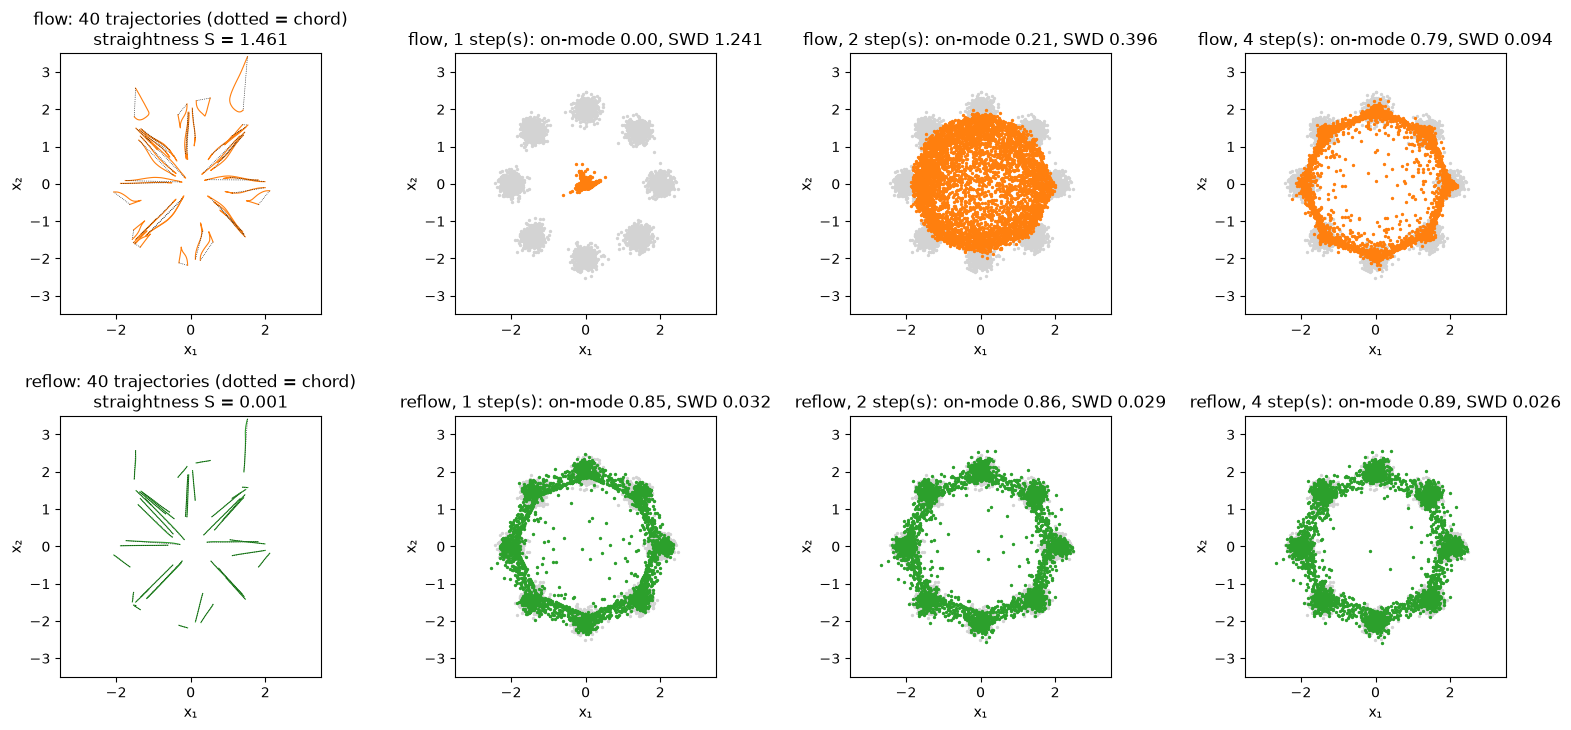

model   steps  on-mode   SWD    mean |x − teacher(100 steps)|   straightness
flow       1    0.00    1.241        1.947                   1.461
flow       2    0.21    0.396        0.646                   1.461
flow       4    0.79    0.094        0.170                   1.461
reflow     1    0.85    0.032        0.078                   0.001
reflow     2    0.86    0.029        0.051                   0.001
reflow     4    0.89    0.026        0.037                   0.001


In [25]:
seed_all(0)
z = torch.randn(NQ, 2)
teacher = euler(as_field(flow_toy), z, 100).cpu()
rows = []
fig, axes = plt.subplots(2, 4, figsize=(16, 7.4))
for r, (name, m, c) in enumerate([("flow", flow_toy, "tab:orange"), ("reflow", reflow_toy, "tab:green")]):
    _, traj = euler(as_field(m), z[:300], 100, return_traj=True)
    S = straightness(traj.cpu())
    ax = axes[r, 0]
    for j in range(40):
        ax.plot(*traj[:, j].cpu().T, c=c, lw=0.8)
        ax.plot(*torch.stack([traj[0, j], traj[-1, j]]).cpu().T, "k:", lw=0.5)
    ax.set(title=f"{name}: 40 trajectories (dotted = chord)\nstraightness S = {S:.3f}", xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
    for ci, n_steps in enumerate([1, 2, 4]):
        xs = euler(as_field(m), z, n_steps).cpu()
        q = quality(xs); dist = (xs - teacher).norm(dim=1).mean().item()
        rows.append((name, n_steps, *q, dist, S))
        ax = axes[r, ci + 1]
        ax.scatter(*REF.T, s=2, c="lightgray"); ax.scatter(*xs.T, s=2, c=c)
        ax.set(title=f"{name}, {n_steps} step(s): on-mode {q[0]:.2f}, SWD {q[1]:.3f}", xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()
print("model   steps  on-mode   SWD    mean |x − teacher(100 steps)|   straightness")
for name, n, om, sw, dist, S in rows:
    print(f"{name:7s} {n:4d}    {om:.2f}    {sw:.3f}        {dist:.3f}                   {S:.3f}")

Reflow straightens the paths: $S$ drops from 1.46 to 0.001, and the reflow trajectories (bottom left) lie on their chords. One reflow step gives on-mode 0.85 and SWD 0.032, against 0.00 / 1.24 for one step of the original flow; at 4 steps, 0.89 / 0.026 vs 0.79 / 0.094. The 1-step reflow sample lies 0.08 from the teacher's 100-step sample for the same noise (original flow: 1.95). It stays below the 100-step teacher in precision (0.95 on-mode): the points between modes are the teacher's own errors, now reproduced in one step. Cost: 20 000 teacher ODE solves of 100 steps and a second training run.
✏️ Reflow cannot be better than its teacher: it learns the teacher's ODE map. Where in the 1-step reflow scatter do you see the teacher's errors (points between modes)? What would a second reflow round do to straightness, and what would it cost?

## 5. Classifier-free guidance on MNIST

The DDPM U-Net from 2d was trained with 10 % null labels, so it predicts both $\hat\varepsilon(x_k\mid y)$ and $\hat\varepsilon(x_k\mid\varnothing)$. Since $\hat\varepsilon = -\sqrt{1-\bar\alpha_k}\,\nabla\log p(x_k)$, the lecture's score combination becomes
$$\hat\varepsilon_w = \hat\varepsilon(x_k\mid\varnothing) + w\,\big(\hat\varepsilon(x_k\mid y) - \hat\varepsilon(x_k\mid\varnothing)\big),$$
$w = 1$: conditional model, $w=0$: unconditional, $w>1$: guided (the lecture's $\gamma$). For a flow the same line acts on $v$ (Lecture 10b: $(1-w)\,v(x\mid\varnothing) + w\,v(x\mid y)$, the same expression); section 6 uses it that way. We write the guided model as a wrapper with the network's own signature, so `ddpm_sample` and `euler` use it unchanged.

In [26]:
def cfg_model(model, w, null):
    def guided(x, t, y):
        out_c, out_u = model(torch.cat([x, x]), torch.cat([t, t]), torch.cat([y, torch.full_like(y, null)])).chunk(2)
        return out_u + w * (out_c - out_u)
    return guided

# Check: w = 1 must equal the conditional call, w = 0 the unconditional one
xc = torch.randn(4, 1, RES, RES, device=device); tc = torch.full((4,), 300.0, device=device); yc = torch.tensor([3, 1, 4, 1], device=device)
with torch.no_grad():
    for w, lab in [(1.0, yc), (0.0, torch.full_like(yc, NULL))]:
        diff = (cfg_model(ddpm_mnist, w, NULL)(xc, tc, yc) - ddpm_mnist(xc, tc, lab)).abs().max().item()
        print(f"w = {w}: max |guided − direct call| = {diff:.2e}")

w = 1.0: max |guided − direct call| = 1.49e-08
w = 0.0: max |guided − direct call| = 0.00e+00


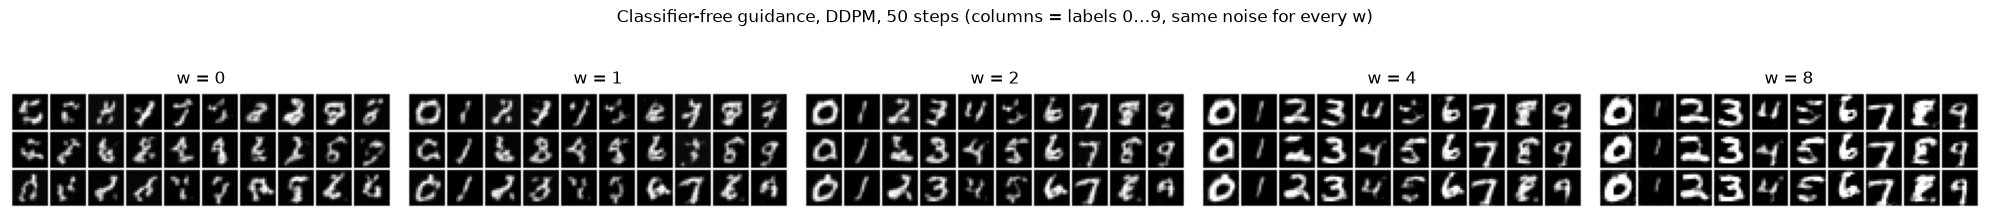

In [27]:
ws = [0.0, 1.0, 2.0, 4.0, 8.0]
y_grid = torch.arange(10).repeat(3).to(device)                 # 3 samples per digit
fig, axes = plt.subplots(1, len(ws), figsize=(4.0 * len(ws), 2.6))
for ax, w in zip(axes, ws):
    xs = ddpm_sample(cfg_model(ddpm_mnist, w, NULL), len(y_grid), trailing_steps(50), shape=(1, RES, RES),
                     y=y_grid, gen=torch.Generator().manual_seed(0))      # the same noise for every w
    show_digits(xs, 10, f"w = {w:g}", ax)
plt.suptitle("Classifier-free guidance, DDPM, 50 steps (columns = labels 0…9, same noise for every w)")
plt.tight_layout(); plt.show()

Same noise, different $w$. At $w=0$ (unconditional) almost nothing is readable. At $w=1$ about half of the 30 samples are the requested digit, at $w=2$ most, at $w=4$ all ten classes are clear. At $w=8$ the strokes are thick and saturated and the three samples of each class look almost alike: guidance has removed most within-class variation. Section 6 measures this.

✏️ Try $w = 15$. What breaks first, and why does extrapolating $\hat\varepsilon$ far beyond both predictions push pixels out of $[-1, 1]$?

## 6. Guidance trades diversity for fidelity

Deployed text-to-image models sample with $w>1$ (Lecture 10b: SD3 uses $w\approx 4$), because samples follow the prompt more closely. In score form, the guided score $\nabla\log p(x) + w\,\nabla\log p(y\mid x)$ targets $p(x)\,p(y\mid x)^w$: the implicit classifier is sharpened, so samples are pushed to where $p(y\mid x)$ is highest, away from every other class. The price is diversity. We measure it on a toy where classes overlap: 8 Gaussians with std 0.45 (neighbouring centers are 1.53 apart, so 1.7 std from the decision boundary), one class per mode.

- **class accuracy**: fraction of class-$y$ samples whose Bayes-optimal label (nearest center, since all modes have equal weight and covariance) is $y$. Real data scores below 1 because the classes overlap.
- **coverage** (recall, Kynkäänniemi et al. 2019): fraction of real class-$y$ points that have a generated class-$y$ sample within radius $r = 0.15$. Generated points that cluster in a smaller region leave real points uncovered.
- **precision** (same paper, roles swapped): fraction of generated class-$y$ samples that have a real class-$y$ point within $r$. It drops when samples leave the data.

All three are averaged over the 8 classes, 500 samples per class, 50 Euler steps, the same noise for every $w$.

In [28]:
def coverage(gen, real, r):
    return (torch.cdist(real, gen).min(1).values < r).float().mean().item()

g_chk, r_chk = torch.randn(500, 2), torch.randn(300, 2)
print(f"mine {coverage(g_chk, r_chk, 0.15):.4f}   scipy cKDTree {(cKDTree(g_chk.numpy()).query(r_chk.numpy())[0] < 0.15).mean():.4f}")

mine 0.8133   scipy cKDTree 0.8133


  step  1000  loss 1.0949


  step  2000  loss 1.0250


  step  3000  loss 1.0162


  step  4000  loss 1.0076
  trained in 38s


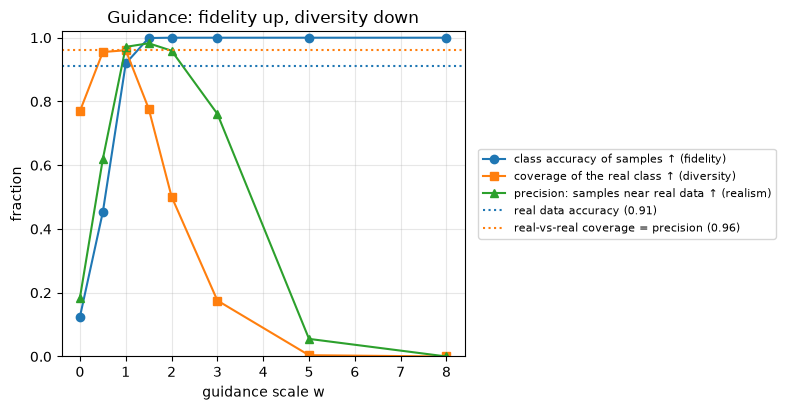

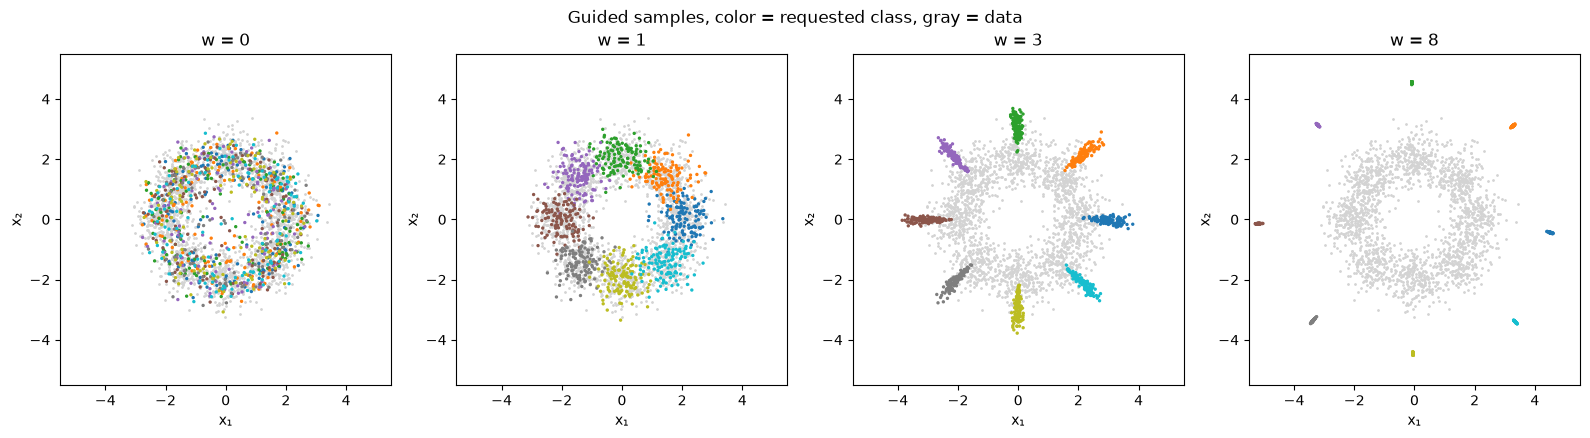

w     accuracy  coverage  precision
 0.0   0.125     0.770     0.184
 0.5   0.454     0.955     0.620
 1.0   0.919     0.961     0.971
 1.5   0.999     0.778     0.983
 2.0   1.000     0.502     0.959
 3.0   1.000     0.175     0.761
 5.0   1.000     0.004     0.055
 8.0   1.000     0.000     0.000
real   0.912     0.960     0.960


In [29]:
STD6 = 0.45
seed_all(0)
NULL8 = 8                                                     # null label for the 8-class toy
toy_cfg_loss = lambda m, x, y: fm_loss(m, x, drop_labels(y, 0.2, NULL8))
cond_toy = train(ToyNet(n_classes=8).to(device), toy_cfg_loss, lambda: toy_batch(std=STD6), steps=4000)

x_real, y_real = eight_gaussians(8000, STD6)
real_acc = (torch.cdist(x_real, CENTERS).argmin(1) == y_real).float().mean().item()
ws6 = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0]
y_gen = torch.arange(8).repeat_interleave(500).to(device)
z = torch.randn(len(y_gen), 2)
acc, cov, prec, samples = [], [], [], {}
for w in ws6:
    xs = euler(as_field(cfg_model(cond_toy, w, NULL8), y_gen), z, 50).cpu()
    samples[w] = xs
    yg = y_gen.cpu()
    acc.append((torch.cdist(xs, CENTERS).argmin(1) == yg).float().mean().item())
    cov.append(np.mean([coverage(xs[yg == c], x_real[y_real == c][:500], 0.15) for c in range(8)]))
    prec.append(np.mean([coverage(x_real[y_real == c][:500], xs[yg == c], 0.15) for c in range(8)]))   # roles swapped
real_cov = np.mean([coverage(x_real[y_real == c][500:1000], x_real[y_real == c][:500], 0.15) for c in range(8)])

fig, ax0 = plt.subplots(figsize=(8, 4.2))
axes = [ax0]
axes[0].plot(ws6, acc, "o-", label="class accuracy of samples ↑ (fidelity)")
axes[0].plot(ws6, cov, "s-", label="coverage of the real class ↑ (diversity)")
axes[0].plot(ws6, prec, "^-", c="tab:green", label="precision: samples near real data ↑ (realism)")
axes[0].axhline(real_acc, c="tab:blue", ls=":", label=f"real data accuracy ({real_acc:.2f})")
axes[0].axhline(real_cov, c="tab:orange", ls=":", label=f"real-vs-real coverage = precision ({real_cov:.2f})")
axes[0].set(xlabel="guidance scale w", ylabel="fraction", title="Guidance: fidelity up, diversity down", ylim=(0, 1.02))
axes[0].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5)); axes[0].grid(alpha=0.3)
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, w in zip(axes, [0.0, 1.0, 3.0, 8.0]):
    ax.scatter(*x_real[:2000].T, s=1, c="lightgray")
    ax.scatter(*samples[w][::4].T, s=2, c=y_gen.cpu()[::4], cmap="tab10")
    ax.set(title=f"w = {w:g}", xlim=(-5.5, 5.5), ylim=(-5.5, 5.5), xlabel="x₁", ylabel="x₂"); ax.set_aspect("equal")
plt.suptitle("Guided samples, color = requested class, gray = data"); plt.tight_layout(); plt.show()
print("w     accuracy  coverage  precision")
for w, a, c, pr in zip(ws6, acc, cov, prec):
    print(f"{w:4.1f}   {a:.3f}     {c:.3f}     {pr:.3f}")
print(f"real   {real_acc:.3f}     {real_cov:.3f}     {real_cov:.3f}")

- At $w=1$ the model matches the data on all three numbers: accuracy 0.92 (data 0.91), coverage 0.96 (0.96), precision 0.97. At $w=0$ (unconditional) accuracy is chance, 0.125, and precision is low because each "class" is spread over the whole ring.
- Raising $w$ buys accuracy fast: 1.00 already at $w=1.5$. Coverage pays: 0.78 at $w=1.5$, 0.50 at $w=2$, 0.18 at $w=3$, ≈ 0 from $w=5$.
- The scatter plots show the mechanism: each class contracts and moves **outward**, away from its neighbours, where $p(y\mid x)$ is highest. At $w=3$ samples sit on the outer edge of their mode; at $w=8$ they are off the data entirely (radius ≈ 4.5–5, data radius 2). Precision registers this: 0.98 at $w=1.5$, 0.76 at $w=3$, 0 at $w=8$, while accuracy stays at 1.00.
- Practical rule: a classifier-based fidelity score (accuracy, CLIP score, Inception Score) keeps rising after samples have left the data. Report a diversity metric (recall/coverage, FID) next to it, and tune $w$ on both.

✏️ Change `STD6` to 0.15 (well-separated classes, accuracy ≈ 1 at $w=1$). Does guidance still cost coverage? Does it buy anything?

## 7. If time: DDIM, the deterministic sampler for the DDPM model

The DDPM network from section 2 also defines an ODE (the probability-flow ODE). DDIM (Song et al., 2021) steps along it without noise:
$$\hat x_0 = \frac{x_k - \sqrt{1-\bar\alpha_k}\,\hat\varepsilon}{\sqrt{\bar\alpha_k}},\qquad x_{k'} = \sqrt{\bar\alpha_{k'}}\,\hat x_0 + \sqrt{1-\bar\alpha_{k'}}\,\hat\varepsilon .$$
Same trained model, no retraining. Compare with ancestral sampling and with flow matching at equal steps.

In [30]:
@torch.no_grad()
def ddim_sample(model, n, ks, shape=(2,)):
    x = torch.randn(n, *shape).to(device)
    ab = abar.to(device)
    for i, k in enumerate(ks):
        ab_prev = ab[ks[i + 1]] if i + 1 < len(ks) else torch.tensor(1.0, device=device)
        eps = model(x, torch.full((n,), k * 1000 / K, device=device))
        x0_hat = (x - (1 - ab[k]).sqrt() * eps) / ab[k].sqrt()
        x = ab_prev.sqrt() * x0_hat + (1 - ab_prev).sqrt() * eps
    return x

seed_all(0)
res_ddim = {n: quality(ddim_sample(ddpm_toy, NQ, trailing_steps(n)).cpu()) for n in STEP_GRID}
print("steps | ancestral on-mode/SWD | DDIM on-mode/SWD | flow on-mode/SWD")
for n in STEP_GRID:
    print(f"{n:5d} |     {res_ddpm[n][0]:.2f} / {res_ddpm[n][1]:.3f}    |   {res_ddim[n][0]:.2f} / {res_ddim[n][1]:.3f}  |  {res_flow[n][0]:.2f} / {res_flow[n][1]:.3f}")

steps | ancestral on-mode/SWD | DDIM on-mode/SWD | flow on-mode/SWD
    1 |     0.03 / 2.298    |   0.03 / 2.300  |  0.00 / 1.241
    2 |     0.00 / 0.772    |   0.00 / 0.884  |  0.21 / 0.392
    4 |     0.29 / 0.360    |   0.23 / 0.403  |  0.77 / 0.095
    8 |     0.74 / 0.101    |   0.75 / 0.102  |  0.89 / 0.064
   16 |     0.86 / 0.062    |   0.84 / 0.057  |  0.92 / 0.045
   32 |     0.91 / 0.051    |   0.88 / 0.056  |  0.94 / 0.039
   64 |     0.93 / 0.053    |   0.90 / 0.058  |  0.95 / 0.044
  200 |     0.94 / 0.025    |   0.91 / 0.037  |  0.95 / 0.026


DDIM does not help on this toy: at every step count it is within a few points of ancestral sampling (on-mode 0.23 vs 0.29 at 4 steps, 0.75 vs 0.74 at 8), and both stay below the flow (0.77, 0.89). Removing the noise removes neither the curvature of the path nor the $1/\sqrt{\bar\alpha}$ amplification in the first step. Practical few-step diffusion samplers add higher-order solvers (DPM-Solver) or change the parameterization (v-prediction, flows).
✏️ Convert the trained DDPM ε-network into a velocity field for the path $x = \sqrt{\bar\alpha}\,x_{\rm data} + \sqrt{1-\bar\alpha}\,\varepsilon$ and sample it with `euler`. Which time variable makes this path closest to straight?

## Summary
- **DDPM**: closed-form noising $q(x_k\mid x_0)$, an ε-regression loss, and an ancestral sampler; checked step by step against `diffusers`. It needs tens of steps.
- **Flow matching**: a straight path, a velocity-regression loss, and an Euler ODE solver; no schedule. On the toy it beats DDPM when steps are few (on-mode 0.77 vs 0.29 at 4 steps) and matches it at many.
- **Reflow** retrains on the model's own (noise, sample) pairs: straightness 1.46 → 0.001, and one step reaches on-mode 0.85 (original flow: 0.00). It is bounded by the teacher's quality.
- **Classifier-free guidance** needs only label dropout at training and two forward passes (one batch) at sampling.
- **Guidance trades diversity for fidelity**: accuracy reaches 1.00 at $w=1.5$ while coverage falls from 0.96 ($w=1$) to 0.18 ($w=3$); from $w=5$ the samples leave the data, which a classifier-based score does not detect.

**Further watching:** MIT 6.S184 *Introduction to Flow Matching and Diffusion Models* (2026), lectures and notes, https://diffusion.csail.mit.edu/2026/ .

**Further reading:** Stanford CME 296 *Diffusion & Large Vision Models* (Spring 2026): [L1 DDPM/DDIM](https://cme296.stanford.edu/slides/spring26-cme296-lecture1.pdf), [L2 score matching](https://cme296.stanford.edu/slides/spring26-cme296-lecture2.pdf), [L3 flow matching / rectified flow](https://cme296.stanford.edu/slides/spring26-cme296-lecture3.pdf), [L5 U-Net / DiT / MM-DiT](https://cme296.stanford.edu/slides/spring26-cme296-lecture5.pdf). Lipman et al., *Flow Matching Guide and Code* (2024).

In [31]:
print(f"total runtime: {(time.time() - T_START) / 60:.1f} min")

total runtime: 2.5 min
